In [6]:
!mamba install pandas
!mamba install numpy
!mamba install matplotlib
!mamba install seaborn
!mamba install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
# Library: sklearn.datasets Used to load the California Housing dataset.
from sklearn.model_selection import train_test_split
# Library sklearn.model_selection Used to split data into training & testing sets.
from sklearn.preprocessing import StandardScaler
# Library: sklearn.preprocessing Used for feature scaling.
from sklearn.linear_model import LinearRegression, Ridge
# Library: sklearn.linear_model LinearRegression → Basic regression model.
# Ridge → Regularized regression model from sklearn.tree
from sklearn.tree import DecisionTreeRegressor
# Library: sklearn.tree Decision Tree regression model.
from sklearn.metrics import mean_squared_error, r2_score
# Library: sklearn.metrics mean_squared_error → Calculates prediction error.
# r2_score → Calculates model performance score.

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.5420999999940395 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.062699999988079 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.0439000000059604 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-f

In [7]:
housing = fetch_california_housing()
print("Feature Names:")
print(housing.feature_names)

print("\nDataset Shape:")
print(housing.data.shape)

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Dataset Shape:
(20640, 8)


               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745554  0.575819
2      Decision Tree  0.703045  0.622811


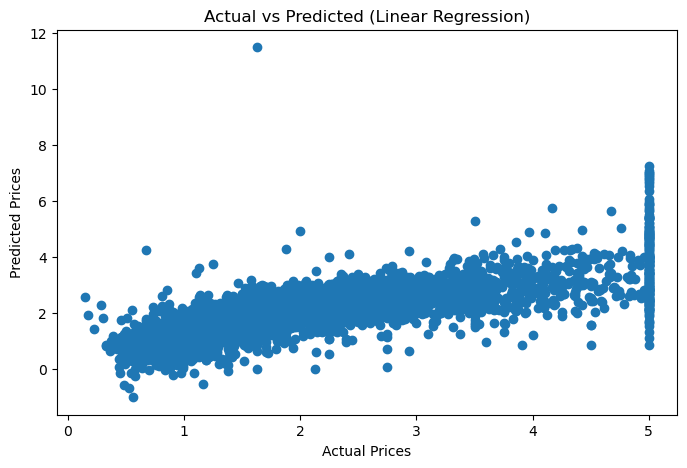

In [12]:
# Features and Target
X = housing.data
y = housing.target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Ridge Regression
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Evaluation
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

lr_r2 = r2_score(y_test, lr_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
dt_r2 = r2_score(y_test, dt_pred)

# Comparison Table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],
    "RMSE": [lr_rmse, ridge_rmse, dt_rmse],
    "R2 Score": [lr_r2, ridge_r2, dt_r2]
})

print(results)

# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [13]:
print(results)

               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745554  0.575819
2      Decision Tree  0.703045  0.622811
